###  Позначення
- \(x_1\) — кількість сайтів  
- \(x_2\) — кількість інтернет-магазинів  
- \(x_3\) — кількість інтеграцій з ERP  

Ціни (тис. \$): \(p_1=2,\ p_2=9,\ p_3=6\).

###  Цільова функція
$$
\max Z = 2x_1 + 9x_2 + 6x_3 \quad (\text{тис.\$})
$$

###  Обмеження (год/міс)
$$
\begin{cases}
12x_1 + 6x_2 + 2x_3 \le 320,\\
12x_1 + 24x_2 + 18x_3 \le 192,\\
12x_1 + 18x_2 + 12x_3 \le 180,\\
x_1, x_2, x_3 \ge 0.
\end{cases}
$$

###  Перехід до рівностей (додаємо слеки \(s_1,s_2,s_3\ge0\))
$$
\begin{cases}
12x_1 + 6x_2 + 2x_3 + s_1 = 320,\\
12x_1 + 24x_2 + 18x_3 + s_2 = 192,\\
12x_1 + 18x_2 + 12x_3 + s_3 = 180.
\end{cases}
$$

---

## Симплекс-таблиці (рядок цілі у вигляді \(Z-c^\top x\))

### Початкова таблиця (базис \(s_1,s_2,s_3\))
$$
\begin{array}{rrrrrrrr}
\text{Базис} & x_1 & x_2 & x_3 & s_1 & s_2 & s_3 & b\\
s_1 & 12 & 6  & 2  & 1 & 0 & 0 & 320\\
s_2 & 12 & 24 & 18 & 0 & 1 & 0 & 192\\
s_3 & 12 & 18 & 12 & 0 & 0 & 1 & 180\\
Z-c^\top x & -2 & -9 & -6 & 0 & 0 & 0 & 0
\end{array}
$$

Вхідна змінна: \(x_2\) (найбільш від’ємний коеф. у рядку цілі \(-9\)).  
Тест відношень \(b/a_{i2}\): \(320/6\approx53.33,\ \ 192/24=8,\ \ 180/18=10\) ⇒ виходить \(s_2\).  
Опорний елемент: \(24\).

 Нормуємо опорний рядок
$$
R_2'=\frac{1}{24}R_2=
\Big[\tfrac{1}{2},\ 1,\ \tfrac{3}{4},\ 0,\ \tfrac{1}{24},\ 0 \ \big|\ 8\Big].
$$

Проміжна таблиця (нормовано тільки \(R_2\)):
$$
\begin{array}{rrrrrrrr}
\text{Базис} & x_1 & x_2 & x_3 & s_1 & s_2 & s_3 & b\\
s_1 & 12 & 6  & 2  & 1 & 0 & 0 & 320\\
x_2 & \tfrac{1}{2} & 1 & \tfrac{3}{4} & 0 & \tfrac{1}{24} & 0 & 8\\
s_3 & 12 & 18 & 12 & 0 & 0 & 1 & 180\\
Z-c^\top x & -2 & -9 & -6 & 0 & 0 & 0 & 0
\end{array}
$$

### Крок 2. Занулюємо стовпець \(x_2\) в інших рядках (кроки Гаусса)
Операції:
$$
R_1 \leftarrow R_1 - 6R_2',\qquad
R_3 \leftarrow R_3 - 18R_2',\qquad
R_Z \leftarrow R_Z + 9R_2'.
$$

Результати перерахунку:
- \(R_1: (9,\ 0,\ -\tfrac{5}{2},\ 1,\ -\tfrac{1}{4},\ 0\ |\ 272)\)  
- \(R_3: (3,\ 0,\ -\tfrac{3}{2},\ 0,\ -\tfrac{3}{4},\ 1\ |\ 36)\)  
- \(R_Z: (\tfrac{5}{2},\ 0,\ \tfrac{3}{4},\ 0,\ \tfrac{3}{8},\ 0\ |\ 72)\)

### Нова таблиця
$$
\begin{array}{rrrrrrrr}
\text{Базис} & x_1 & x_2 & x_3 & s_1 & s_2 & s_3 & b\\
s_1 & 9 & 0 & -\tfrac{5}{2} & 1 & -\tfrac{1}{4} & 0 & 272\\
x_2 & \tfrac{1}{2} & 1 & \tfrac{3}{4} & 0 & \tfrac{1}{24} & 0 & 8\\
s_3 & 3 & 0 & -\tfrac{3}{2} & 0 & -\tfrac{3}{4} & 1 & 36\\
Z-c^\top x & \tfrac{5}{2} & 0 & \tfrac{3}{4} & 0 & \tfrac{3}{8} & 0 & 72
\end{array}
$$

Критерій зупинки для max із рядком \(Z-c^\top x\): у нижньому рядку всі коефіцієнти не від’ємні ⇒ оптимум досягнуто.

### Оптимальний план і значення
$$
x_1^*=0,\qquad x_2^*=8,\qquad x_3^*=0,\qquad
Z^* = 72\ \text{тис.\$}.
$$

Перевірка ресурсів: дизайнери \(6\cdot8=48\le320\); розробники \(24\cdot8=192\) (активне); тестування \(18\cdot8=144\le180\).



In [1]:
try:
    import numpy as np
    from scipy.optimize import linprog

    # ціль: max 2x1 + 9x2 + 6x3  ->  min - (..)
    c = -np.array([2, 9, 6], dtype=float)

    A = np.array([
        [12,  6,  2],   # дизайнери <= 320
        [12, 24, 18],   # розробники <= 192
        [12, 18, 12],   # тестувальники <= 180
    ], dtype=float)

    b = np.array([320, 192, 180], dtype=float)

    bounds = [(0, None), (0, None), (0, None)]

    res = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method="highs")
    x1, x2, x3 = res.x
    z  = -res.fun

    print("Status:", res.message)
    print(f"x1={x1:.6f}, x2={x2:.6f}, x3={x3:.6f}")
    print(f"Optimal revenue Z = {z:.2f} (тис. $)")
except Exception as e:
    print("Error:", e)


Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
x1=0.000000, x2=8.000000, x3=0.000000
Optimal revenue Z = 72.00 (тис. $)


Візуалізація в площині (x1, x2) при x3=0

заштрихована допустима область;

кілька ізоліній цілі
𝑍
=
2
𝑥
1
+
9
𝑥
2
Z=2x
1
	​

+9x
2
	​

 для x3=0;

позначка оптимуму
(
0
,
8
)
(0,8).

У вимогах – без seaborn та стилів, окремі фігури ✔️

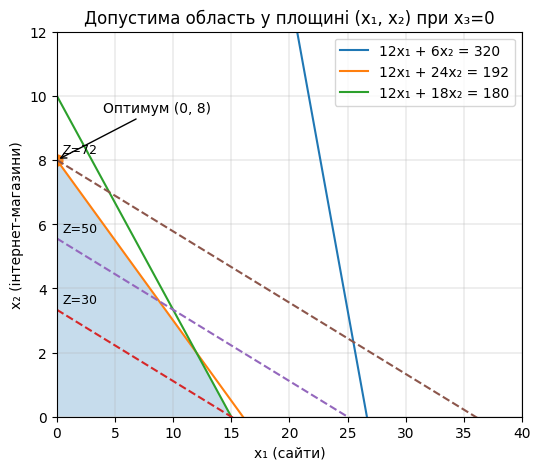

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x1_max = 40
x1 = np.linspace(0, x1_max, 400)

y1 = (320 - 12*x1) / 6        # 12x1 + 6x2 <= 320
y2 = (192 - 12*x1) / 24       # 12x1 + 24x2 <= 192
y3 = (180 - 12*x1) / 18       # 12x1 + 18x2 <= 180


y_cap = np.minimum(np.minimum(y1, y2), y3)
y_cap = np.clip(y_cap, 0, None)

plt.figure(figsize=(6, 5))
plt.plot(x1, y1, label="12x₁ + 6x₂ = 320")
plt.plot(x1, y2, label="12x₁ + 24x₂ = 192")
plt.plot(x1, y3, label="12x₁ + 18x₂ = 180")

plt.fill_between(x1, 0, y_cap, alpha=0.25)


Z_levels = [30, 50, 72]
for Zlv in Z_levels:
    yZ = (Zlv - 2*x1)/9
    plt.plot(x1, yZ, linestyle="--")
    # підпис в точці перетину з віссю x2
    if Zlv >= 0:
        plt.text(0.5, Zlv/9 + 0.2, f"Z={Zlv}", fontsize=9)

# Оптимум (з розв'язку)
plt.scatter([0], [8], s=60)
plt.annotate("Оптимум (0, 8)", xy=(0, 8), xytext=(4, 9.5),
             arrowprops=dict(arrowstyle="->"))

plt.xlim(0, x1_max)
plt.ylim(0, max(12, y_cap.max()+2))
plt.xlabel("x₁ (сайти)")
plt.ylabel("x₂ (інтернет-магазини)")
plt.title("Допустима область у площині (x₁, x₂) при x₃=0")
plt.legend(loc="upper right")
plt.grid(True, linewidth=0.3)
plt.show()


3) Візуалізація в площині (x2, x3) при x1=0

корисно побачити, що оптимум лежить на осі
𝑥
3
=
0
x
3
	​

=0.

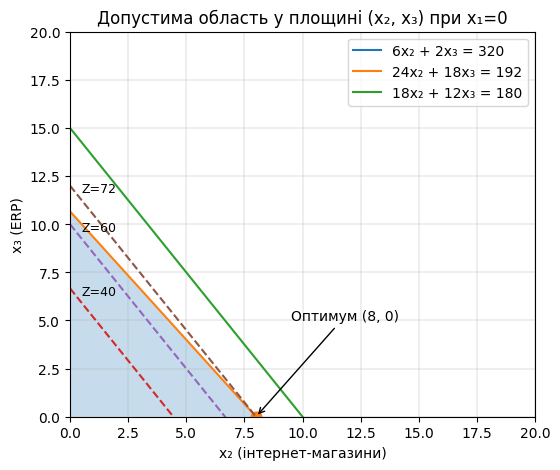

In [3]:
x2_max = 20
x2 = np.linspace(0, x2_max, 400)

z1 = (320 - 6*x2) / 2      # 6x2 + 2x3 <= 320
z2 = (192 - 24*x2) / 18    # 24x2 + 18x3 <= 192
z3 = (180 - 18*x2) / 12    # 18x2 + 12x3 <= 180

z_cap = np.minimum(np.minimum(z1, z2), z3)
z_cap = np.clip(z_cap, 0, None)

plt.figure(figsize=(6, 5))
plt.plot(x2, z1, label="6x₂ + 2x₃ = 320")
plt.plot(x2, z2, label="24x₂ + 18x₃ = 192")
plt.plot(x2, z3, label="18x₂ + 12x₃ = 180")
plt.fill_between(x2, 0, z_cap, alpha=0.25)

Z_levels = [40, 60, 72]
for Zlv in Z_levels:
    zZ = (Zlv - 9*x2)/6
    plt.plot(x2, zZ, linestyle="--")
    plt.text(0.5, (Zlv - 9*0.5)/6 + 0.4, f"Z={Zlv}", fontsize=9)

plt.scatter([8], [0], s=60)
plt.annotate("Оптимум (8, 0)", xy=(8, 0), xytext=(9.5, 5),
             arrowprops=dict(arrowstyle="->"))

plt.xlim(0, x2_max)
plt.ylim(0, max(20, z_cap.max()+2))
plt.xlabel("x₂ (інтернет-магазини)")
plt.ylabel("x₃ (ERP)")
plt.title("Допустима область у площині (x₂, x₃) при x₁=0")
plt.legend(loc="upper right")
plt.grid(True, linewidth=0.3)
plt.show()


4) Швидка перевірка «якісної» причини оптимуму

In [4]:
revenue = np.array([2, 9, 6], dtype=float)
dev_hours = np.array([12, 24, 18], dtype=float)

print("Дохід на 1 годину РОЗРОБНИКА:")
for name, val in zip(["x1 (сайт)", "x2 (e-shop)", "x3 (ERP)"], revenue/dev_hours):
    print(f"{name:10s}: {val:.3f} тис.$/год")

best = np.argmax(revenue/dev_hours)
print("\nНайбільше дає x2 (e-shop) => логічно, що оптимум у куті x2=8, x1=x3=0.")


Дохід на 1 годину РОЗРОБНИКА:
x1 (сайт) : 0.167 тис.$/год
x2 (e-shop): 0.375 тис.$/год
x3 (ERP)  : 0.333 тис.$/год

Найбільше дає x2 (e-shop) => логічно, що оптимум у куті x2=8, x1=x3=0.
